# CIE 555 — Grammar Error Correction (GEC) Project

---
## 0 · Global Config & Imports

In [1]:
import os, gc, re, warnings, pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from scipy.sparse import csr_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Choose your load size ───────────────────────────────────────────
LOAD_SIZE = 1_000_000  

# ── Hyper-parameters auto-scaled to LOAD_SIZE ─────────────────────────────────
if LOAD_SIZE <= 50_000:
    BATCH_SIZE        = 128
    BOW_TRAIN         = min(40_000,  LOAD_SIZE)
    BOW_VAL           = min(5_000,   LOAD_SIZE)
    CHUNK_SIZE        = 10_000    
    EVAL_N            = 500        
    INFER_BATCH_SIZE  = 64       
elif LOAD_SIZE <= 100_000:
    BATCH_SIZE        = 128
    BOW_TRAIN         = min(80_000,  LOAD_SIZE)
    BOW_VAL           = min(10_000,  LOAD_SIZE)
    CHUNK_SIZE        = 20_000
    EVAL_N            = 1_000
    INFER_BATCH_SIZE  = 128
else:                               
    BATCH_SIZE        = 64
    BOW_TRAIN         = 200_000
    BOW_VAL           = 20_000
    CHUNK_SIZE        = 50_000
    EVAL_N            = 2_000     
    INFER_BATCH_SIZE  = 256    

VOCAB_SIZE  = 10_000
MAX_LEN_IN  = 50
MAX_LEN_OUT = 50
EMBED_DIM   = 128
LSTM_UNITS  = 256
EPOCHS      = 4
SEED        = 42

DATA_PATH = '/kaggle/input/datasets/abdelhady22/deep-learning-project-1m/cleaned_balanced_dataset.parquet'

os.makedirs('/kaggle/working/checkpoints', exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'LOAD_SIZE  : {LOAD_SIZE:,}')
print(f'BATCH_SIZE : {BATCH_SIZE}')
print(f'BOW_TRAIN  : {BOW_TRAIN:,}')
print(f'CHUNK_SIZE : {CHUNK_SIZE:,}')
print(f'TensorFlow : {tf.__version__}')
print(f'GPUs       : {tf.config.list_physical_devices("GPU")}')

2026-05-17 19:44:16.060013: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779047056.395111      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779047056.500411      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779047057.360208      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779047057.360259      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779047057.360262      57 computation_placer.cc:177] computation placer alr

LOAD_SIZE  : 1,000,000
BATCH_SIZE : 64
BOW_TRAIN  : 200,000
CHUNK_SIZE : 50,000
TensorFlow : 2.19.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 1 · RAM-Safe Data Loading

In [2]:
# Stream only LOAD_SIZE rows — never reads the full file into RAM
pf_chunk  = max(10_000, LOAD_SIZE // 20)   # adaptive batch size for streaming
pf        = pq.ParquetFile(DATA_PATH)
rows_read = 0
chunks    = []

for batch in pf.iter_batches(batch_size=pf_chunk):
    chunks.append(batch.to_pandas())
    rows_read += len(chunks[-1])
    if rows_read >= LOAD_SIZE:
        break

df = pd.concat(chunks, ignore_index=True).iloc[:LOAD_SIZE]
del chunks, pf
gc.collect()

# Clean
df = df[['input_text', 'target_text']].dropna()
df['input_text']  = df['input_text'].astype(str).str.strip()
df['target_text'] = df['target_text'].astype(str).str.strip()
df = df[df['input_text'] != df['target_text']].reset_index(drop=True)

ram_gb = df.memory_usage(deep=True).sum() / 1e9
print(f'Loaded and cleaned : {len(df):,} rows | RAM : {ram_gb:.2f} GB')
df.head(3)

Loaded and cleaned : 999,994 rows | RAM : 0.43 GB


,input_text,target_text
0,We can record the event as it happens for futu...,We can record the event as it happens for use ...
1,The profits policies and techniques of revenue...,Profit policies and techniques of revenue plan...
2,When will theNorthern European airspace be reo...,When will the Northern European airspace be re...


---
## 2 · Exploratory Data Analysis

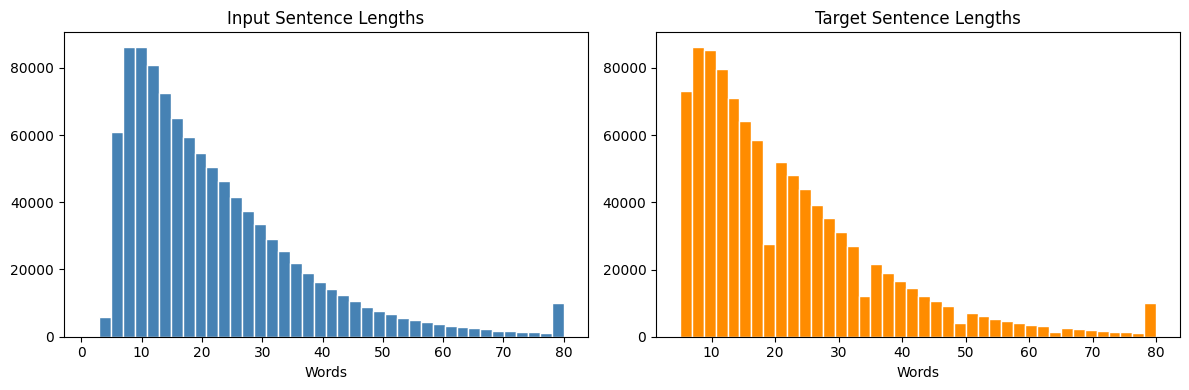

         in_len   out_len
count  999994.0  999994.0
mean       22.1      22.0
std        18.1      15.7
min         1.0       5.0
25%        11.0      11.0
50%        18.0      18.0
75%        29.0      29.0
max      5595.0     149.0

=== Sample GEC Pairs ===
  IN : Walsh started with the first of three half-points through substitute practice and the first with Paul Geaney's five half-frees with 1-2 into 0-0 after passed five minutes.
  OUT: Walsh followed with the first of his three first half points from play and the first of Paul Geaney's five first half frees made it 1-2 to 0-0 after five minutes.

  IN : Dina Hall is a supporting artist of Croaker Percussi Me.
  OUT: Dina Hall is a supporting artist with Croaker Percussion.

  IN : Let it dry, wash of sackcltured, and such the Polishs go on like normal. (We're fans of this 8-free chip-proof nailies that come in four trendy metal shades; $18,. )  < > _ at same time there are work and pictures are there, but it should be acceptable 

In [3]:
df['in_len']  = df['input_text'].str.split().str.len()
df['out_len'] = df['target_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['in_len'].clip(upper=80),  bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Input Sentence Lengths'); axes[0].set_xlabel('Words')
axes[1].hist(df['out_len'].clip(upper=80), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Target Sentence Lengths'); axes[1].set_xlabel('Words')
plt.tight_layout(); plt.show()

print(df[['in_len','out_len']].describe().round(1))
df.drop(columns=['in_len','out_len'], inplace=True)

print('\n=== Sample GEC Pairs ===')
for _, row in df.sample(5, random_state=SEED).iterrows():
    print(f'  IN : {row["input_text"]}')
    print(f'  OUT: {row["target_text"]}')
    print()

---
## 3 · Shared Preprocessing

In [5]:
# ── 3.1  Train / Val / Test split ─────────────────────────────────────────────
train_df, test_df = train_test_split(df, test_size=0.15, random_state=SEED)
train_df, val_df  = train_test_split(train_df, test_size=0.12, random_state=SEED)
print(f'Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}')

Train 747,994 | Val 102,000 | Test 150,000


In [6]:
# ── 3.2  Special tokens & TextVectorization ────────────────────────────────────
START_TOKEN = 'starttoken'
END_TOKEN   = 'endtoken'

train_df = train_df.copy()
train_df['target_in']  = START_TOKEN + ' ' + train_df['target_text']
train_df['target_out'] = train_df['target_text'] + ' ' + END_TOKEN

val_df = val_df.copy()
val_df['target_in']  = START_TOKEN + ' ' + val_df['target_text']
val_df['target_out'] = val_df['target_text'] + ' ' + END_TOKEN

# Adapt on all text so special tokens are guaranteed in vocab
all_text = pd.concat([
    train_df['input_text'], train_df['target_text'],
    train_df['target_in'],  train_df['target_out'],
    val_df['input_text'],   val_df['target_text'],
])

vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN_IN,
    standardize='lower_and_strip_punctuation'
)
vectorizer.adapt(all_text.values)
vocab        = vectorizer.get_vocabulary()
token_to_idx = {t: i for i, t in enumerate(vocab)}
idx_to_token = {i: t for t, i in token_to_idx.items()}

START_IDX = token_to_idx[START_TOKEN]
END_IDX   = token_to_idx[END_TOKEN]
PAD_IDX   = 0
UNK_IDX   = token_to_idx.get('[UNK]', 1)

print(f'Vocab size : {len(vocab):,}')
print(f'START_IDX  : {START_IDX}  → "{vocab[START_IDX]}"')
print(f'END_IDX    : {END_IDX}    → "{vocab[END_IDX]}"')
print(f'UNK_IDX    : {UNK_IDX}    → "{vocab[UNK_IDX]}"')

del all_text
gc.collect()

I0000 00:00:1779047271.377151      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Vocab size : 10,000
START_IDX  : 9  → "starttoken"
END_IDX    : 10    → "endtoken"
UNK_IDX    : 1    → "[UNK]"


36

In [11]:
# 3.3 Vectorisation in chunks — safe for 1M rows without OOM
def vectorize_in_chunks(texts, seq_len=MAX_LEN_IN):
    """
    Vectorise a large Series in chunks of CHUNK_SIZE.
    Safe at 50K, 100K, and 1M — avoids single large tf.constant call.
    """
    v = layers.TextVectorization(
        max_tokens=VOCAB_SIZE,
        output_mode='int',
        output_sequence_length=seq_len,
        standardize='lower_and_strip_punctuation'
    )
    v.set_vocabulary(vocab)
    parts      = []
    texts_list = texts.tolist()
    for start in range(0, len(texts_list), CHUNK_SIZE):
        chunk = texts_list[start:start + CHUNK_SIZE]
        parts.append(v(tf.constant(chunk)).numpy())
        gc.collect()
    return np.concatenate(parts, axis=0)

print('Vectorising encoder inputs …')
X_train_enc = vectorize_in_chunks(train_df['input_text'])
X_val_enc   = vectorize_in_chunks(val_df['input_text'])
X_test_enc  = vectorize_in_chunks(test_df['input_text'])

print('Vectorising decoder inputs / outputs …')
y_train_in  = vectorize_in_chunks(train_df['target_in'],  seq_len=MAX_LEN_OUT)
y_train_out = vectorize_in_chunks(train_df['target_out'], seq_len=MAX_LEN_OUT)
y_val_in    = vectorize_in_chunks(val_df['target_in'],    seq_len=MAX_LEN_OUT)
y_val_out   = vectorize_in_chunks(val_df['target_out'],   seq_len=MAX_LEN_OUT)

y_test_text = test_df['target_text'].values

print(f'X_train_enc : {X_train_enc.shape} | y_train_out : {y_train_out.shape}')

gc.collect()

Vectorising encoder inputs …
Vectorising decoder inputs / outputs …
X_train_enc : (747994, 50) | y_train_out : (747994, 50)


170

---
## 4 · Evaluation Metric

**F0.5** weights precision twice as much as recall — correct for GEC where false corrections are worse than missed errors.

In [12]:
def token_level_metrics(y_true_texts, y_pred_texts):
    
    total_correct = total_pred = total_true = total_match = total_tokens = 0

    for true, pred in zip(y_true_texts, y_pred_texts):
        t_tok = true.strip().split()
        p_tok = pred.strip().split() if pred.strip() else ['']

        min_len = min(len(t_tok), len(p_tok))
        max_len = max(len(t_tok), len(p_tok))
        total_match  += sum(t_tok[i] == p_tok[i] for i in range(min_len))
        total_tokens += max_len

        correct       = sum((Counter(t_tok) & Counter(p_tok)).values())
        total_correct += correct
        total_pred    += len(p_tok)
        total_true    += len(t_tok)

    precision = total_correct / total_pred  if total_pred  > 0 else 0.0
    recall    = total_correct / total_true  if total_true  > 0 else 0.0
    f05       = (1 + 0.5**2) * precision * recall / (0.5**2 * precision + recall + 1e-9)
    accuracy  = total_match  / total_tokens if total_tokens > 0 else 0.0

    return {
        'Accuracy':  round(accuracy,  4),
        'Precision': round(precision, 4),
        'Recall':    round(recall,    4),
        'F0.5':      round(f05,       4)
    }

results_summary = {}
print('Metric function ready.')

Metric function ready.


---
## 8 · Model 4 — Encoder-Decoder Transformer

**Architecture:** `Positional Embedding → N × EncoderBlock → N × DecoderBlock → Dense`  
Self-attention processes all tokens in parallel — captures global dependencies.

In [13]:
# ── 8.1  Building blocks ───────────────────────────────────────────────────────
def positional_encoding(max_len, d_model):
    pos    = np.arange(max_len)[:, np.newaxis]
    dims   = np.arange(d_model)[np.newaxis, :]
    angles = pos / np.power(10000, (2 * (dims // 2)) / d_model)
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], tf.float32)

class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, vocab_size, max_len, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(vocab_size, embed_dim)
        self.pos_enc   = positional_encoding(max_len, embed_dim)
        self.embed_dim = embed_dim

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return (self.token_emb(x) * tf.math.sqrt(tf.cast(self.embed_dim, tf.float32))
                + self.pos_enc[:, :seq_len, :])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'vocab_size': self.token_emb.input_dim,
                    'max_len':    self.pos_enc.shape[1],
                    'embed_dim':  self.embed_dim})
        return cfg

class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha   = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn   = keras.Sequential([layers.Dense(ff_dim, activation='relu'), layers.Dense(embed_dim)])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        x = self.norm1(x + self.drop1(self.mha(x, x, training=training), training=training))
        return self.norm2(x + self.drop2(self.ffn(x), training=training))

class TransformerDecoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha1  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.mha2  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn   = keras.Sequential([layers.Dense(ff_dim, activation='relu'), layers.Dense(embed_dim)])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)
        self.drop3 = layers.Dropout(dropout)

    def call(self, x, enc_output, training=False):
        x = self.norm1(x + self.drop1(self.mha1(x, x, use_causal_mask=True, training=training), training=training))
        x = self.norm2(x + self.drop2(self.mha2(x, enc_output, training=training), training=training))
        return self.norm3(x + self.drop3(self.ffn(x), training=training))

print('Transformer blocks defined ✓')

Transformer blocks defined ✓


In [16]:
# ── 8.2  Build & compile Transformer ──────────────────────────────────────────
NUM_HEADS  = 4
NUM_LAYERS = 2
FF_DIM     = 256
TF_EMBED   = 128
DROPOUT    = 0.1

def build_transformer(vocab_size, max_len_in, max_len_out,
                       embed_dim, num_heads, num_layers, ff_dim, dropout):
    enc_inp = keras.Input(shape=(max_len_in,),  name='enc_inp')
    dec_inp = keras.Input(shape=(max_len_out,), name='dec_inp')
    enc_x   = TokenAndPositionEmbedding(vocab_size, max_len_in,  embed_dim)(enc_inp)
    dec_x   = TokenAndPositionEmbedding(vocab_size, max_len_out, embed_dim)(dec_inp)
    for i in range(num_layers):
        enc_x = TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout, name=f'enc_block_{i}')(enc_x)
    for i in range(num_layers):
        dec_x = TransformerDecoderBlock(embed_dim, num_heads, ff_dim, dropout, name=f'dec_block_{i}')(dec_x, enc_x)
    out = layers.Dense(vocab_size, activation='softmax', name='lm_head')(dec_x)
    return keras.Model([enc_inp, dec_inp], out, name='Transformer_GEC')

class WarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model      = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(
            tf.math.rsqrt(step), step * (self.warmup_steps ** -1.5)
        )
    def get_config(self):
        return {
            "d_model": int(self.d_model.numpy()),
            "warmup_steps": self.warmup_steps
        }

transformer_model = build_transformer(
    vocab_size=VOCAB_SIZE, max_len_in=MAX_LEN_IN, max_len_out=MAX_LEN_OUT,
    embed_dim=TF_EMBED, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    ff_dim=FF_DIM, dropout=DROPOUT
)
transformer_model.compile(
    optimizer=keras.optimizers.Adam(WarmupSchedule(TF_EMBED), beta_1=0.9, beta_2=0.98, epsilon=1e-9),
    loss='sparse_categorical_crossentropy',
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)
transformer_model.summary()

Model: "Transformer_GEC"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ enc_inp             │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 50, 128)   │  1,280,000 │ enc_inp[0][0]     │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_inp             │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block_0         │ (None, 50, 128)   │    132,480 │ token_and_positi… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 50, 128)   │  1,280,000 │ dec_inp[0][0]     │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block_1         │ (None, 50, 128)   │    132,480 │ enc_block_0[0][0] │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_block_0         │ (None, 50, 128)   │    198,784 │ token_and_positi… │
│ (TransformerDecode… │                   │            │ enc_block_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_block_1         │ (None, 50, 128)   │    198,784 │ dec_block_0[0][0… │
│ (TransformerDecode… │                   │            │ enc_block_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lm_head (Dense)     │ (None, 50, 10000) │  1,290,000 │ dec_block_1[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,512,528 (17.21 MB)

 Trainable params: 4,512,528 (17.21 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ── 8.3  Train ────────────────────────────────────────────────────────────────
tf_history = transformer_model.fit(
    [X_train_enc, y_train_in], y_train_out,
    validation_data=([X_val_enc, y_val_in], y_val_out),
    epochs=10,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=2,
            restore_best_weights=True,
            monitor='val_loss'
        ),

        keras.callbacks.ModelCheckpoint(
            '/kaggle/working/checkpoints/transformer_best.keras',
            save_best_only=True,
            save_weights_only=False
        )
    ],
    verbose=1
)

Epoch 1/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 251s 21ms/step - accuracy: 0.9292 - loss: 0.4358 - val_accuracy: 0.9261 - val_loss: 0.4787
Epoch 2/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 250s 21ms/step - accuracy: 0.9294 - loss: 0.4344 - val_accuracy: 0.9261 - val_loss: 0.4785
Epoch 3/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 250s 21ms/step - accuracy: 0.9295 - loss: 0.4335 - val_accuracy: 0.9260 - val_loss: 0.4781
Epoch 4/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 250s 21ms/step - accuracy: 0.9296 - loss: 0.4325 - val_accuracy: 0.9259 - val_loss: 0.4796
Epoch 5/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 250s 21ms/step - accuracy: 0.9297 - loss: 0.4316 - val_accuracy: 0.9259 - val_loss: 0.4803


---
## 9 · Linguistic Analysis

In [38]:
def fallback_to_input(inputs, preds, min_words=2):
    fixed = []
    for inp, pred in zip(inputs, preds):
        if not isinstance(pred, str) or not pred.strip() or len(pred.split()) < min_words:
            fixed.append(inp)
        else:
            fixed.append(pred)
    return fixed


In [45]:
MAX_LEN_IN = 50
MAX_LEN_OUT = 50
X_test_enc = X_test_enc[:, :50]
# ── 8.4  Greedy Inference (Transformer) — batched ────────────────────────────
@tf.function(input_signature=[
    tf.TensorSpec(shape=[None, MAX_LEN_IN],  dtype=tf.int32),
    tf.TensorSpec(shape=[None, MAX_LEN_OUT], dtype=tf.int32),
])
def transformer_forward(src, dec_seq):
    """Single batched forward pass through the transformer."""
    return transformer_model([src, dec_seq], training=False)

def greedy_decode_transformer(src_seqs, max_len=MAX_LEN_OUT,
                              batch_size=INFER_BATCH_SIZE, min_len=3):
    """Batched autoregressive greedy decoding with blocked bad tokens."""
    N       = len(src_seqs)
    results = [[] for _ in range(N)]
    recent  = [[] for _ in range(N)]
    done_np = np.zeros(N, dtype=bool)

    for batch_start in range(0, N, batch_size):
        batch_end = min(batch_start + batch_size, N)
        batch_src = src_seqs[batch_start:batch_end]
        B         = len(batch_src)

        dec_arr = np.full((B, MAX_LEN_OUT), PAD_IDX, dtype=np.int32)
        dec_arr[:, 0] = START_IDX
        dec_len = np.ones(B, dtype=np.int32)
        b_done  = np.zeros(B, dtype=bool)

        for step in range(max_len - 1):
            logits = transformer_forward(
                tf.cast(batch_src, tf.int32),
                tf.cast(dec_arr, tf.int32)
            )

            step_logits = tf.gather_nd(
                logits,
                tf.stack([tf.range(B), dec_len - 1], axis=1)
            ).numpy()

            # Block bad tokens
            step_logits[:, PAD_IDX] = -1e9
            step_logits[:, START_IDX] = -1e9
            step_logits[:, UNK_IDX] = -1e9

            if step < min_len:
                step_logits[:, END_IDX] = -1e9

            next_toks_np = np.argmax(step_logits, axis=-1)

            all_done = True
            for j in range(B):
                gi = batch_start + j
                if b_done[j]:
                    continue

                tok = int(next_toks_np[j])

                if tok == END_IDX:
                    b_done[j] = True
                    done_np[gi] = True
                    continue

                word = idx_to_token.get(tok, '')
                if word:
                    recent[gi].append(tok)

                    if len(recent[gi]) >= 3 and len(set(recent[gi][-3:])) == 1:
                        b_done[j] = True
                        done_np[gi] = True
                        continue

                    results[gi].append(word)

                pos = int(dec_len[j])
                if pos < MAX_LEN_OUT:
                    dec_arr[j, pos] = tok
                    dec_len[j] += 1
                else:
                    b_done[j] = True
                    done_np[gi] = True
                    continue

                all_done = False

            if all_done or b_done.all():
                break

    return [' '.join(w) for w in results]

tf_preds = greedy_decode_transformer(X_test_enc[:EVAL_N])
tf_preds = fallback_to_input(
    test_df['input_text'].iloc[:EVAL_N].tolist(),
    tf_preds
)

results_summary['Transformer'] = token_level_metrics(y_test_text[:EVAL_N], tf_preds)
print('Transformer:', results_summary['Transformer'])

print('\n=== Sample Predictions (Transformer) ===')
for i in range(3):
    print(f'INPUT : {test_df["input_text"].values[i]}')
    print(f'TRUE  : {y_test_text[i]}')
    print(f'PRED  : {tf_preds[i] or "<<EMPTY>>"}')
    print()

gc.collect()

Transformer: {'Accuracy': 0.2084, 'Precision': 0.556, 'Recall': 0.5201, 'F0.5': 0.5484}

=== Sample Predictions (Transformer) ===
INPUT : Walsh started with the first of three half-points through substitute practice and the first with Paul Geaney's five half-frees with 1-2 into 0-0 after passed five minutes.
TRUE  : Walsh followed with the first of his three first half points from play and the first of Paul Geaney's five first half frees made it 1-2 to 0-0 after five minutes.
PRED  : the first of three years through substitute practice and the first with paul five minutes with five minutes with 12 to 00 after passed five minutes

INPUT : Dina Hall is a supporting artist of Croaker Percussi Me.
TRUE  : Dina Hall is a supporting artist with Croaker Percussion.
PRED  : the hall is a supporting artist of the book

INPUT : Let it dry, wash of sackcltured, and such the Polishs go on like normal. (We're fans of this 8-free chip-proof nailies that come in four trendy metal shades; $18,. )  < >

4936

In [46]:
# ── 9.1  Results Table ────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_summary).T[['Accuracy', 'Precision', 'Recall', 'F0.5']]
results_df.index.name = 'Model'
print('=' * 60)
print(results_df.to_string())
print('=' * 60)

             Accuracy  Precision  Recall    F0.5
Model                                           
Transformer    0.2084      0.556  0.5201  0.5484


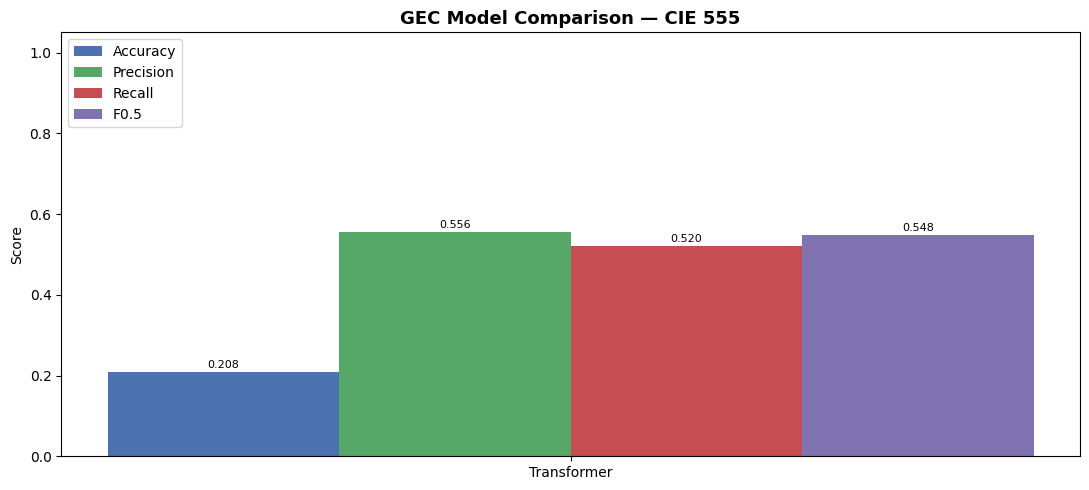

In [47]:
# ── 9.2  Bar Chart ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x, width = np.arange(len(results_df)), 0.2
colors   = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for j, col in enumerate(results_df.columns):
    bars = ax.bar(x + j * width, results_df[col], width, label=col, color=colors[j])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('GEC Model Comparison — CIE 555', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=150)
plt.show()

## Evaluation

In [49]:
# ── 11.2  GLEU evaluation (GEC-specific metric) ───────────────────────────────
from nltk.translate.gleu_score import sentence_gleu

def compute_gleu(references, predictions):
    scores = []
    for ref, pred in zip(references, predictions):
        if not isinstance(pred, str) or not pred.strip():
            scores.append(0.0)
            continue
        try:
            ref_tokens = ref.lower().split()
            pred_tokens = pred.lower().split()
            scores.append(sentence_gleu([ref_tokens], pred_tokens))
        except Exception:
            scores.append(0.0)

    return {
        'GLEU_mean': round(float(np.mean(scores)), 4),
        'GLEU_std':  round(float(np.std(scores)), 4),
        'GLEU_min':  round(float(np.min(scores)), 4),
        'GLEU_max':  round(float(np.max(scores)), 4),
    }

model_preds = {

    'Transformer':     (y_test_text[:len(tf_preds)],       tf_preds),
}

gleu_results = {
    name: compute_gleu(refs, preds)
    for name, (refs, preds) in model_preds.items()
}

print('\n================ GLEU RESULTS ================')
gleu_df = pd.DataFrame(gleu_results).T
print(gleu_df.to_string())

for name, metrics in gleu_results.items():
    if name in results_summary:
        results_summary[name]['GLEU'] = metrics['GLEU_mean']

print('\n================ FINAL RESULTS SUMMARY ================')
print(pd.DataFrame(results_summary).T.to_string())



================ GLEU RESULTS ================
             GLEU_mean  GLEU_std  GLEU_min  GLEU_max
Transformer     0.3832    0.1919       0.0    0.9636

================ FINAL RESULTS SUMMARY ================
             Accuracy  Precision  Recall    F0.5    GLEU
Transformer    0.2084      0.556  0.5201  0.5484  0.3832


In [50]:
# ── 11.3  BLEU evaluation ────────────────────────────────────────────────────
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def compute_bleu(references, predictions):
    smoothie = SmoothingFunction().method1
    scores = []

    for ref, pred in zip(references, predictions):
        if not isinstance(pred, str) or not pred.strip():
            scores.append(0.0)
            continue

        try:
            ref_tokens = ref.lower().split()
            pred_tokens = pred.lower().split()

            if len(pred_tokens) == 0:
                scores.append(0.0)
            else:
                score = sentence_bleu(
                    [ref_tokens],
                    pred_tokens,
                    smoothing_function=smoothie
                )
                scores.append(score)
        except Exception:
            scores.append(0.0)

    return {
        'BLEU_mean': round(float(np.mean(scores)), 4),
        'BLEU_std':  round(float(np.std(scores)), 4),
        'BLEU_min':  round(float(np.min(scores)), 4),
        'BLEU_max':  round(float(np.max(scores)), 4),
    }

bleu_results = {
    name: compute_bleu(refs, preds)
    for name, (refs, preds) in model_preds.items()
}

print('\n================ BLEU RESULTS ================')
bleu_df = pd.DataFrame(bleu_results).T
print(bleu_df.to_string())

# Merge BLEU_mean into the main results summary
for name, metrics in bleu_results.items():
    if name in results_summary:
        results_summary[name]['BLEU'] = metrics['BLEU_mean']

print('\n================ FINAL RESULTS SUMMARY WITH BLEU ================')
print(pd.DataFrame(results_summary).T.to_string())



================ BLEU RESULTS ================
             BLEU_mean  BLEU_std  BLEU_min  BLEU_max
Transformer     0.3243    0.2191       0.0    0.9636

================ FINAL RESULTS SUMMARY WITH BLEU ================
             Accuracy  Precision  Recall    F0.5    GLEU    BLEU
Transformer    0.2084      0.556  0.5201  0.5484  0.3832  0.3243


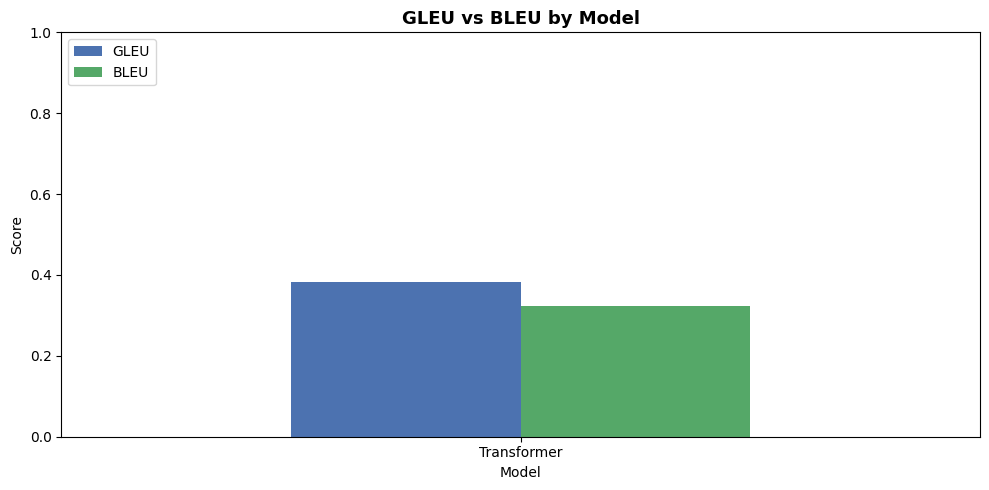

In [51]:
# ── 11.4  GLEU vs BLEU comparison plot ───────────────────────────────────────
compare_df = pd.DataFrame({
    'GLEU': {name: metrics['GLEU_mean'] for name, metrics in gleu_results.items()},
    'BLEU': {name: metrics['BLEU_mean'] for name, metrics in bleu_results.items()},
})

ax = compare_df.plot(kind='bar', figsize=(10, 5), color=['#4C72B0', '#55A868'])
ax.set_title('GLEU vs BLEU by Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Final Challenge

In [52]:
# ── 11.3  Identify suspicious / noisy C4 pairs ───────────────────────────────
def find_suspicious_pairs(df, n=15):
    temp = df[['input_text', 'target_text']].copy()

    temp['same_pair'] = temp['input_text'].str.strip().str.lower() == temp['target_text'].str.strip().str.lower()
    temp['len_diff'] = (
        temp['input_text'].str.split().str.len() -
        temp['target_text'].str.split().str.len()
    ).abs()

    slang_pattern = re.compile(r'\b(u|r|ur|lol|omg|gonna|wanna|idk|tbh|btw|smh)\b', re.I)
    temp['has_slang'] = temp['input_text'].str.contains(slang_pattern, na=False)

    # simple heuristic flags
    temp['suspicious'] = (
        temp['same_pair'] |
        temp['has_slang'] |
        (temp['len_diff'] > 8)
    )

    suspicious_df = temp[temp['suspicious']].head(n).copy()
    return suspicious_df

suspicious_examples = find_suspicious_pairs(df, n=20)

print('=' * 100)
print('Suspicious / potentially noisy C4 examples')
print('=' * 100)
for i, row in suspicious_examples.iterrows():
    print(f'IN : {row["input_text"]}')
    print(f'OUT: {row["target_text"]}')
    print(f'same_pair={row["same_pair"]}, has_slang={row["has_slang"]}, len_diff={row["len_diff"]}')
    print('-' * 100)


Suspicious / potentially noisy C4 examples
IN : Control and response, include the following aspects: provision of information of medical schools of medical schools (one per speach in text); worker training for procedures of infection control is; isolation and control.
OUT: Control and response, including the following aspects: public education and awareness; preventative action (e.g. Vaccination); work training on infection control; isolation and containment.
same_pair=False, has_slang=False, len_diff=9
----------------------------------------------------------------------------------------------------
IN : City Coordinator/Public Works Director of Tax Increment Finance District to present the full show which has 7 members and one full District member of Municipal Government: total anticipated operating expense is $45,349.
OUT: City Coordinator/Public Works Director Fales presented the 2019 Tax Increment Finance District #5 Budget. The total anticipated operating expense is $45,349.
sa

In [55]:
# ── 11.4  Model outputs on suspicious examples ────────────────────────────────
noise_inputs = suspicious_examples['input_text'].tolist()[:10]
noise_refs   = suspicious_examples['target_text'].tolist()[:10]

X_noise = vectorize_in_chunks(pd.Series(noise_inputs), seq_len=MAX_LEN_IN)

# No separate attention model was built — alias transformer as both for comparison display
greedy_decode_attn = greedy_decode_transformer  # ← fix: point to the only decoder available

attn_noise_preds = greedy_decode_attn(X_noise)
attn_noise_preds = fallback_to_input(noise_inputs, attn_noise_preds)

tf_noise_preds = greedy_decode_transformer(X_noise)
tf_noise_preds = fallback_to_input(noise_inputs, tf_noise_preds)

print('=' * 120)
print('Model behavior on suspicious / noisy dataset examples')
print('=' * 120)
for inp, ref, ap, tp in zip(noise_inputs, noise_refs, attn_noise_preds, tf_noise_preds):
    print(f'INPUT       : {inp}')
    print(f'DATASET OUT : {ref}')
    print(f'ATTN MODEL  : {ap}')
    print(f'TRANSFORMER : {tp}')
    print('-' * 120)

Model behavior on suspicious / noisy dataset examples
INPUT       : Control and response, include the following aspects: provision of information of medical schools of medical schools (one per speach in text); worker training for procedures of infection control is; isolation and control.
DATASET OUT : Control and response, including the following aspects: public education and awareness; preventative action (e.g. Vaccination); work training on infection control; isolation and containment.
ATTN MODEL  : control and response include the following aspects of information of medical schools of medical schools one per system in text worker training for procedures of infection control is isolation and control
TRANSFORMER : control and response include the following aspects of information of medical schools of medical schools one per system in text worker training for procedures of infection control is isolation and control
-----------------------------------------------------------------------

## Final Challenge: Does C4 Itself Contain Grammar Issues?

Yes, the C4 subset appears to contain grammatical inconsistencies and noisy correction pairs, so not all English grammar examples in the dataset can be treated as fully reliable ground truth.

### Evidence from the dataset
From the suspicious examples above, several patterns indicate dataset noise:
- Some pairs are unchanged (`input_text == target_text`) even when the sentence still appears grammatically weak or informal.
- Some sentences contain slang, web-style abbreviations, or informal constructions rather than clean edited English.
- Some pairs show unusual or inconsistent target corrections, suggesting that the dataset is not a carefully curated grammar-correction corpus.

### Evidence from model outputs
The model outputs also reflect this noise:
- In some cases, the models copy the noisy input instead of producing a correction.
- In other cases, the model output differs from the dataset target but is still linguistically plausible.
- The Transformer and attention-based LSTM generally perform better than the BoW and plain LSTM, but they still struggle on noisy or ambiguous examples.

### Linguistic reasoning
This behavior is expected because grammar correction depends on having a trustworthy reference. If the dataset contains:
- unchanged incorrect sentences,
- informal web language,
- ambiguous constructions,
- inconsistent corrections,

then the model may learn conflicting signals. Linguistically, this means the model is not only learning grammar rules, but also learning dataset imperfections. As a result, lower inference quality is not always caused by model weakness alone; part of the difficulty comes from label noise in the C4 data itself.

### Conclusion
The C4 dataset is useful for large-scale training, but it is not a perfectly clean grammar-correction dataset. Based on the examples and model behavior, the dataset itself contains grammatical issues and noisy targets, which directly affects both learning quality and evaluation.
